![picture](https://www.clubexcelencia.org/sites/default/files/fotos/images/noticias/visionarios/universidadzaragoza01.jpg)

# <a name="top"></a>Tutorial of wavAImidiZ Library

Authors: Carlos Hernández and José Ramón Beltrán 

Department of Electronic Engineering and Communications, Universidad de Zaragoza, Calle María de Luna 3, 50018 Zaragoza

This notebook shows an example of the usage of the library <span style="font-family:courier new">**wavAImidiZ**</span>. 

beta.0 (June 2020) version

## Dependencies 

* [Numpy](https://numpy.org/)
* [Matplotlib](https://matplotlib.org/)
* [Scipy](https://www.scipy.org/)
* [Magenta](https://github.com/magenta/magenta)
* [pretty_midi](https://github.com/craffel/pretty-midi)
* [Crepe](https://github.com/marl/crepe)
* [Soundfile](https://github.com/bastibe/SoundFile)
* [mir_eval](https://craffel.github.io/mir_eval/)
* [Pandas](https://pypi.org/project/pandas/)

## Modules


This library consists on different modules which are the following ones:

* **<span style="font-family:courier new">midiprocessing.py</span>**: for extract information from MIDI files and plot pianorolls.

    * Class **MidiProcessing**: process a MIDI file with **<span style="font-family:courier new">pretty_midi</span>** library.
    
    * Class **Pianoroll**: plot pianorolls given the tuple [pitch, note on, note off] of an instrument ot track. It also plots and subplots pianorolls of more than one instrument.
    
    * Function **writemidtrack**: creates a track given the tuple [pitch, note on, note off].
    
    * Function **savemiditrack**: saves the MIDI file in disk given the track created with <span style="font-family:courier new">writemidtrack</span> function, the output path and the name of the MIDI file.
    
    * Function **lists_to_tuple**: converts the lists of pitch, note on and note off events in a 3 tuple [pitch, note on, note off] of numpy arrays.
    
    * Function **note_sequence_to_tuple**: converts a note sequence in a 3 tuple [pitch, note on, note off] of numpy arrays.




* **<span style="font-family:courier new">crepe_processing.py</span>**: for computing the wav to MIDI conversion.

    * Class **WavMidi**: performs the pitch estimation with crepe neural network and the tracking algorithms.
    
    * Class **Histogram**: estimates the minimum confidence with 3 different methods ['otsu', 'gaussian', 'triangulation'] to later perform the MIDI tracking algorithm.


* **<span style="font-family:courier new">transcription_metrics.py</span>**: for testing the transcription metrics of the generated MIDI file with the ground truth in the case we have it.

    * Function **sequence_to_valued_intervals**: <span style="font-family:courier new">mir_eval</span> function to convert a note sequence into a valued interval in order to compute the metrics.
    
    * Function **onsets_metrics**: performs the onset metrics (for a time tolerance of 50ms) and prints them.

    * Function **offsets_metrics**: performs the offset metrics (for a time tolerance of 50ms) and prints them.

    * Function **all_metrics**: performs the overall metrics (taking also the pitch into account) and prints them.


<img src="https://4.bp.blogspot.com/-WELZsAfX1U0/Vl7UxvJNHdI/AAAAAAAAF34/9Kl1x1y0Uv4/s1600/separador.png" style="width:500px;"/>

## Table of Contents

- [0. Import](#import)

- [1. Ground Truth Extraction from Reference MIDI](#gtextract)
    
- [2. Pitch Prediction from wav with Crepe](#crepe)
    
- [3. Tracking Algorithm](#crepetracking)
    - [3.1. Minimum Confidence Estimation](#crepeconf)
    - [3.2. Writing Raw Pitch Prediction to MIDI](#creperaw)
    - [Tracking Algorithm from Pitch Prediction](#tracking)
    
- [4. Getting Notes Sequences from Tracks or MIDI Files](#noteseq)

- [5. Plotting Pianorolls](#pianorolls)
    - [5.1. Plotting Single Track Pianorolls](#singlepianoroll)
    - [5.2. Comparing Multiple Track Pianorolls](#comparepianorolls)
         
- [6. Computing Metrics](#metrics)
    - [6.1. Onsets Metrics](#onsetsmetrics)
    - [6.2. Offsetst Metrics](#offsetsmetrics)
    - [6.3. Overall Metrics](#allmetrics)
    - [6.4. Display Metrics](#displaymetrics)

- [References](#references)

## <a name="import"></a>0. IMPORT MODULES AND PATH SETTING

In [1]:
import magenta.music as mm

import sys
#sys.path.insert(0, 'H:\\INVESTIGACION\\Proyectos\\AIBeatz\\scripts\\')
import transcription_metrics
import crepe_processing
import midiprocessing

%matplotlib inline

In [2]:
#path setting
dataset_path = 'H:\\INVESTIGACION\\Proyectos\\AIBeatz\\datasets\\Training dataset 01\\Rap\\'
song = 'All the stars (kendrick lamar)'

path = dataset_path + song + '\\'

#Wav stem or isolated after sources separation
stem_path = path + 'stems\\' 
source_file = 'FRETLESS'
source_infile = stem_path + source_file + '.wav'
 
#Full MIDI ground truth
midi_name = 'mid' + '.mid'
midi_infile = path + midi_name

## <a name="gtextract"></a>1. GROUND TRUTH EXTRACTION FROM REFERENCE MIDI

If we have a MIDI file aligned with the wav file we can extract the track of the instrument from it in order to compare the ground truth with the track (or MIDI file) we'll generate after running crepe tracking algorithm. We do this before because we'll estimate the bpm of the ground truth MIDI file so we'll write the tracks and MIDI files of the crepe prediction with this value of bpm.

Bpm extraction is done with the subclass **<span style="font-family:courier new">estimate_bpm</span>** in **<span style="font-family:courier new">MidiProcessing</span>** class which uses **<span style="font-family:courier new">pretty_midi</span>** library.

In [3]:
m_gt = midiprocessing.MidiProcessing(path + 'mid.mid')

In [4]:
bpm = m_gt.estimate_bpm()

We can print the list of instruments and tracks with the help of **<span style="font-family:courier new">print_tracks</span>** subclass of **<span style="font-family:courier new">MidiProcessing</span>** class that is buid on **<span style="font-family:courier new">pretty_midi</span>** library.

In [5]:
all_tracks = m_gt.get_tracks()

In [6]:
m_gt.print_tracks()

Track no: 0 | Program no: 0 | Track name: MELODY SZA | is drum: False
Track no: 1 | Program no: 0 | Track name: MELODY KL | is drum: False
Track no: 2 | Program no: 0 | Track name: MELODY 1 | is drum: False
Track no: 3 | Program no: 0 | Track name: NEW AGE | is drum: False
Track no: 4 | Program no: 0 | Track name: STRINGS | is drum: False
Track no: 5 | Program no: 0 | Track name: WARM PAD | is drum: False
Track no: 6 | Program no: 0 | Track name: SYN STRINGS 1 | is drum: False
Track no: 7 | Program no: 0 | Track name: POLYSYNTH | is drum: False
Track no: 8 | Program no: 0 | Track name: FRETLESS | is drum: False
Track no: 9 | Program no: 0 | Track name: DRUMS | is drum: True
Track no: 10 | Program no: 0 | Track name: E. PIANO 1 | is drum: False
Track no: 11 | Program no: 0 | Track name: CLEAN GTR | is drum: False
Track no: 12 | Program no: 0 | Track name: SWEEP PAD | is drum: False
Track no: 13 | Program no: 0 | Track name: BOWED | is drum: False


We can obtain or tuple of [pitch, note on, note off] from a single track of the full MIDI file with **<span style="font-family:courier new">get_notestuple_of_singletrack_by_name</span>** subclass by giving the name of the track or we can obtain the tuple giving the number of the program of the track to **<span style="font-family:courier new">get_notestuple_of_singletrack_by_nprogram</span>** subclass.

All these subclasses belong to **<span style="font-family:courier new">MidiProcessing</span>** class which takes a MIDI file to process.

In [7]:
gt_matrix = m_gt.get_notestuple_of_singletrack_by_name('FRETLESS')

In [8]:
gt_track = midiprocessing.writemidtrack(gt_matrix)

## <a name="crepe"></a>2. PITCH PREDICTION FROM WAV WITH CREPE 

The first step is to performe the pitch extraction by Crepe. There is a class which allows us to perform this which is called **<span style="font-family:courier new">Crepe</span>** and which is located in **<span style="font-family:courier new">crepe_processing.py</span>**

In [9]:
wavfile = crepe_processing.WavMidi(source_infile)

time, midi_notes, confidence = wavfile.pitch_estimation()

## <a name="crepetracking"></a>3. TRACKING ALGORITHM

### <a name="crepeconf"></a>3.1. MINIMUM CONFIDENCE ESTIMATION

We will estimate the minimum confidence to run the tracking algortihm taking the information in the histograms within 3 methods:

* Otsu's thresholding
* Gaussian fitting curve
* Triangulation algorithm

The class that allows us to perform these 3 methods is: **<span style="font-family:courier new">Histogram</span>** which is located in **<span style="font-family:courier new">crepe_processing.py</span>**

In [10]:
minc = crepe_processing.Histogram(confidence)

Then we'll use subclass **<span style="font-family:courier new">min_confidence_estimation</span>** to estimate the minimum confidence to then apply the tracking algorithm. We can change the name between '' for 'otsu', 'triangulation' or 'gaussian' depending on which method do we prefer to apply to obtain the minimum confidence. Setting the variable plot = True we'll get the plot of the histogram and we can also add a title to the plot by setting plot_title variable equal to the title between ''.

In [11]:
min_conf = minc.min_confidence_estimation('triangulation')

H:\INVESTIGACION\Proyectos\AIBeatz\scripts\crepe_processing.py:682: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, n = np.linalg.lstsq(A, y_coords)[0]


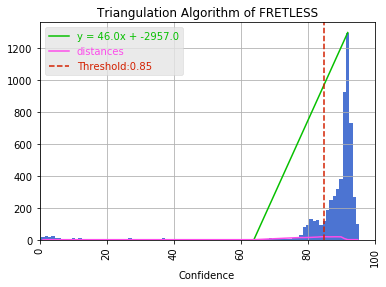

In [12]:
min_conf = minc.min_confidence_estimation('triangulation', True, 'Triangulation Algorithm of {}'.format(source_file))

### <a name="creperaw"></a>3.2. WRITING RAW PITCH PREDICTION TO MIDI

Now, we can obtain the tuple of (pitch, note on, note off) for each note predicted by Crepe. We'll use the class descrived before **<span style="font-family:courier new">Crepe</span>** and its subclass **<span style="font-family:courier new">rawcrepe2midi</span>**

In [13]:
raw_matrix = wavfile.rawcrepe2midi(time, midi_notes, bpm)

We can write the MIDI track from the tuple of (pitch, note on, note off) with the function **<span style="font-family:courier new">writemiditrack</span>**

In [14]:
raw_track = midiprocessing.writemidtrack(raw_matrix)

We also can write the MIDI file in disk with the subclass <span style="font-family:courier new">**savemiditrack**</span> function

In [15]:
midiprocessing.savemiditrack(raw_track, stem_path, source_file + '_crepe_raw')

FRETLESS_crepe_raw .mid has been saved in: H:\INVESTIGACION\Proyectos\AIBeatz\datasets\Training dataset 01\Rap\All the stars (kendrick lamar)\stems\


### <a name="tracking"></a>3.3. TRACKING ALGORITHM FROM PITCH PREDICTION

We can follow the same procedure in 3.2. now to generate the final MIDI file

In [16]:
tracking_matrix = wavfile.crepe_tracking(time, midi_notes, confidence, min_conf, bpm)

In [17]:
tracking_track = midiprocessing.writemidtrack(tracking_matrix)

In [18]:
midiprocessing.savemiditrack(tracking_track, stem_path, source_file)

FRETLESS .mid has been saved in: H:\INVESTIGACION\Proyectos\AIBeatz\datasets\Training dataset 01\Rap\All the stars (kendrick lamar)\stems\


## <a name="noteseq"></a>4. GETTING NOTE SEQUENCES FROM TRACKS OR MIDI FILES

We can obtain note sequences from tracks with magenta.music function **<span style="font-family:courier new">midi_to_note_sequence</span>** or from MIDI files with magenta.music function **<span style="font-family:courier new">midi_file_to_sequence_proto</span>**:

In [19]:
#Ground truth track to note sequence
note_seq_gt = mm.midi_to_note_sequence(gt_track)
#note_seq_gt = mm.midi_file_to_sequence_proto(stem_path + source_file + 'CREPE_tracked.mid')

#MIDI from CREPE track to note sequence
note_seq = mm.midi_to_note_sequence(tracking_track)
#note_seq = mm.midi_file_to_sequence_proto(stem_path + source_file + 'CREPE_tracked222' + '.mid')

## <a name="pianorolls"></a>5. PLOTTING PIANOROLLS

We can plot the pianoroll of 2 or more tracks calling the following subclasses of **<span style="font-family:courier new">Pianoroll</span>** class:

* **<span style="font-family:courier new">plot_singletrack_pianoroll</span>**: plots a single track giving as an input the tuple of (pitch, note on and note off).

* **<span style="font-family:courier new">overlap_multitrack_pianorolls</span>**: plots two or more tracks overlapped in different colors giving as an input the tuples of (pitch, note on and note off) of the different tracks.

* **<span style="font-family:courier new">subplot_pianoroll</span>**: plots two or more tracks in different subplots giving as an input the tuples of (pitch, note on and note off) of the different tracks.

### <a name="singlepianoroll"></a>5.1. PLOTTING SINGLE TRACK PIANOROLLS

We can plot a single track pianoroll from a tuple of [pitch, note on, note off] with the subclass **<span style="font-family:courier new">plot_singletrack_pianoroll</span>** of **<span style="font-family:courier new">Pianoroll</span>** class in **<span style="font-family:courier new">midiprocessing.py</span>** script:

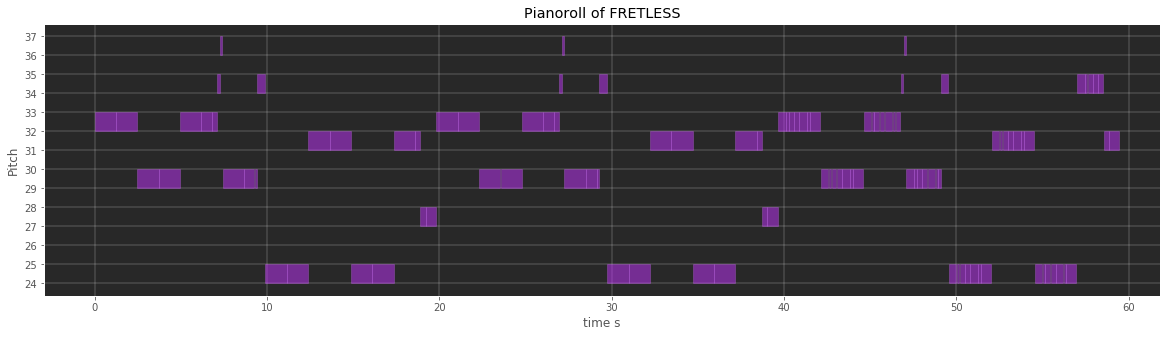

In [20]:
plotpianoroll = midiprocessing.Pianoroll()
plotpianoroll.plot_singletrack_pianoroll(gt_matrix, plot_title='Pianoroll of FRETLESS')

If we have a note sequence and we want to plot its pianoroll, we can transform the note sequence into a tuple of [pitch, note on and note off] with the function **<span style="font-family:courier new">note_sequence_to_tuple</span>** in **<span style="font-family:courier new">midiprocessing.py</span>** script

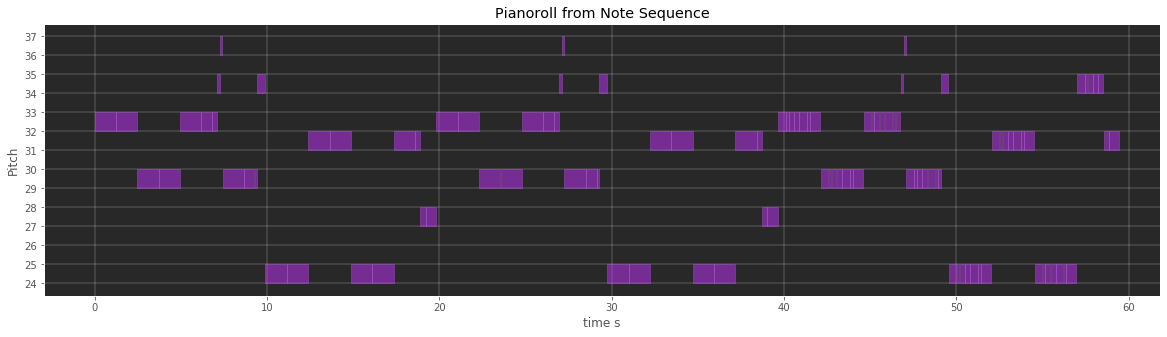

In [21]:
tuple_gt = midiprocessing.note_sequence_to_tuple(note_seq_gt)
plotpianoroll.plot_singletrack_pianoroll(tuple_gt, 'Pianoroll from Note Sequence')

(We can check that both pianorolls avobe plotted from the tuple of [pitch, note on, note off] and after converting the note sequence into a tuple are the same)

### <a name="comparepianorolls"></a>5.2. COMPARING MULTIPLE TRACK PIANOROLLS

If we want to plot more than one single track pianoroll we can use **<span style="font-family:courier new">overlap_multitrack_pianorolls</span>** to overlap the tracks in a single plot or **<span style="font-family:courier new">subplot_pianoroll</span>** to plot the tracks in different subplots.

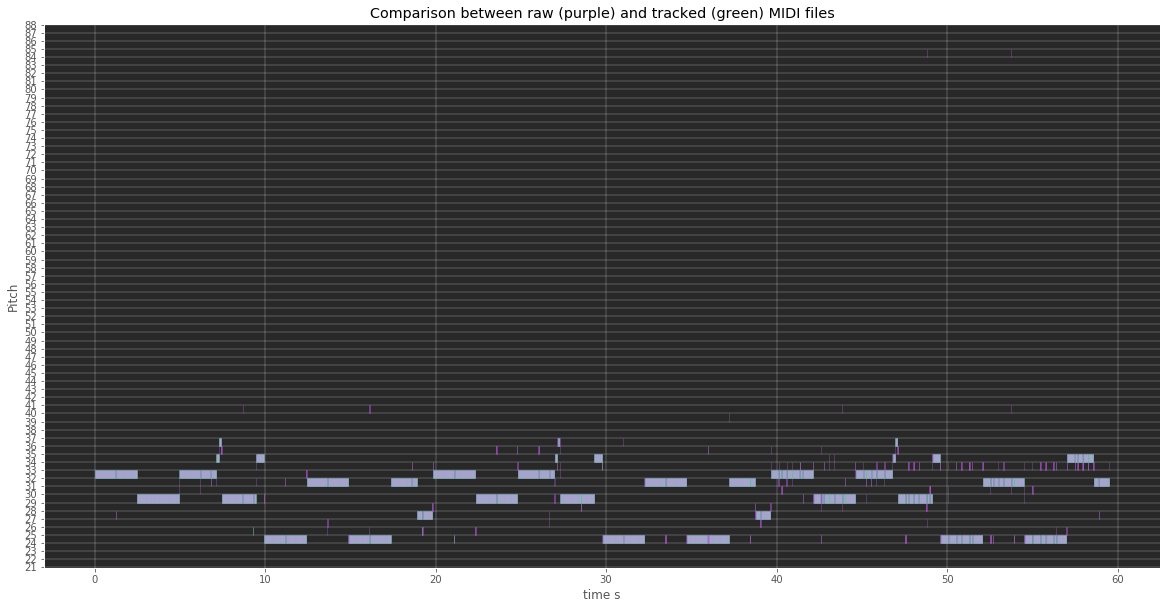

In [22]:
#Comparison plot raw vs tracked MIDI file
plotpianoroll.overlap_multitrack_pianorolls(raw_matrix, tracking_matrix,
        plot_title='Comparison between raw (purple) and tracked (green) MIDI files')

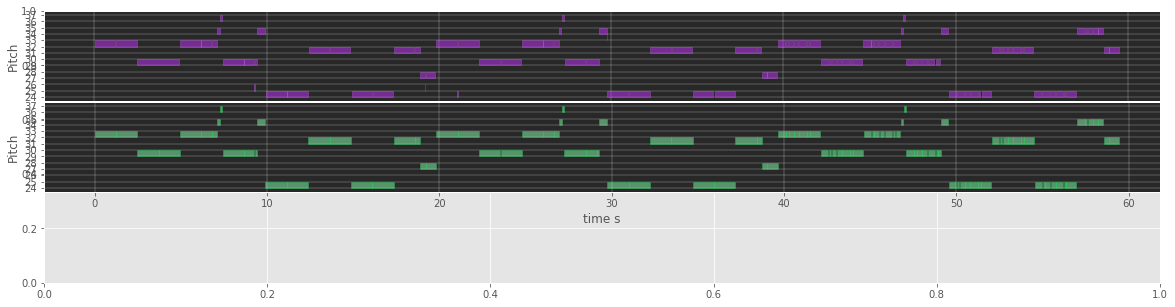

In [23]:
#Plot generated MIDI with CREPE vs Ground Truth
plotpianoroll.subplot_pianoroll(tracking_matrix, gt_matrix,
        plot_title='Comparison between CREPE (green) and ground truth (purple) MIDI files')

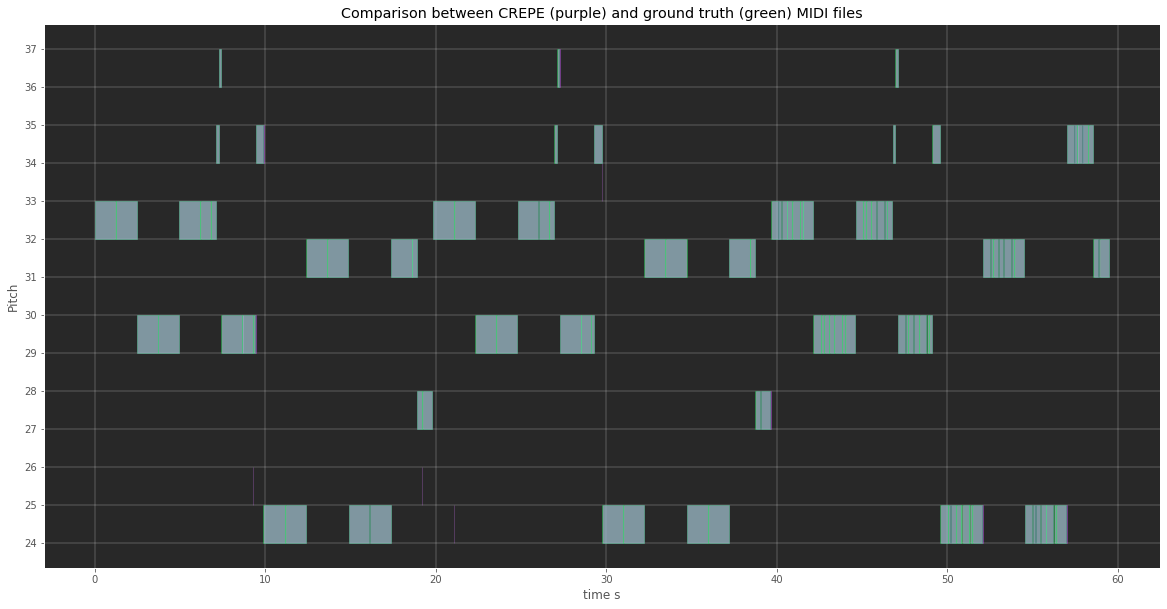

In [24]:
#Comparison plot tracked MIDI file vs ground truth
plotpianoroll.overlap_multitrack_pianorolls(tracking_matrix, gt_matrix,
        plot_title='Comparison between CREPE (purple) and ground truth (green) MIDI files')

## <a name="metrics"></a>6. COMPUTING METRICS

We can compute the onsets, offsets and the metrics taking also the pitch into account with <span style="font-family:courier new">**mir_eval**</span> library. The <span style="font-family:courier new">**transcription_metrics.py**</span> script takes the functions of the library and print the metrics with the True Positives, False Positives and False Negatives. 

The functions in this script are the following ones:


* **<span style="font-family:courier new">sequence_to_valued_intervals: mir_eval</span>** function to convert a note sequence into a valued interval in order to compute the metrics.

* **<span style="font-family:courier new">onsets_metrics</span>**: performs the onset metrics (for a time tolerance of 50ms) and prints them.

* **<span style="font-family:courier new">offsets_metrics</span>**: performs the offset metrics (for a time tolerance of 50ms) and prints them.

* **<span style="font-family:courier new">all_metrics</span>**: performs the overall metrics (taking also the pitch into account) and prints them.

In [25]:
valued_int_gt = transcription_metrics.sequence_to_valued_intervals(note_seq_gt)

valued_int = transcription_metrics.sequence_to_valued_intervals(note_seq)

In [26]:
#Variables to compute metrics
ref_intervals = valued_int_gt[0]
ref_pitches = 440*2**((valued_int_gt[1]-69)/12)
est_intervals = valued_int[0]
est_pitches = 440*2**((valued_int[1]-69)/12)

### <a name="onsetsmetrics"></a>6.1. ONSETS METRICS

In [27]:
onsets = transcription_metrics.onsets_metrics(ref_intervals, est_intervals)   

________________________________
          ONSETS METRICS        
________________________________
True Positives: 85
False Positives: 19
False Negatives: 20
Onset Precision is: 81.73 %
Onset Recall is: 80.95 %
Onset F-measure is: 81.34 %


### <a name="offsetsmetrics"></a>6.2. OFFSETS METRICS

In [28]:
offsets = transcription_metrics.offsets_metrics(ref_intervals, est_intervals)

________________________________
        OFFSETS METRICS         
________________________________
True Positives: 100
False Positives: 3
False Negatives: 5
Offset Precision is: 96.15 %
Offset Recall is: 95.24 %
Offset F-measure is: 95.69 %


### <a name="allsmetrics"></a>6.3. OVERALL METRICS

In [29]:
metrics = transcription_metrics.all_metrics(ref_intervals, ref_pitches, est_pitches, est_intervals)

________________________________
          FINAL METRICS         
________________________________
True Positives: 80
False Positives: 23
False Negatives: 25
Precision is: 76.92 %
Recall is: 76.19 %
F-measure is: 76.56 %


### <a name="displaymetrics"></a>6.1. DISPLAY METRICS

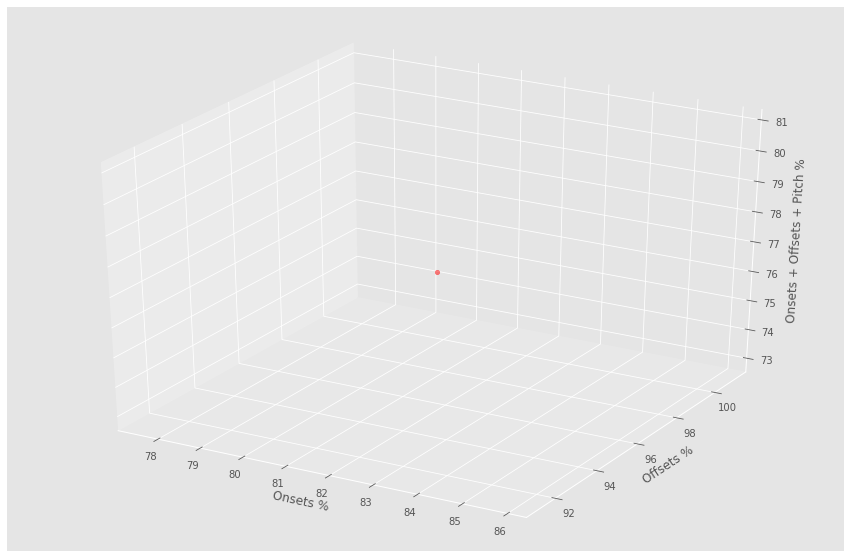

In [30]:
transcription_metrics.plot_metrics(onsets[0], offsets[0], metrics[0])

We can save the results in a csv file with the function <span style="font-family:courier new">**write_metrics_data**</span>:

In [33]:
transcription_metrics.write_metrics_csv(onsets, offsets, metrics, path)

File metrics.csv has been stored in H:\INVESTIGACION\Proyectos\AIBeatz\datasets\Training dataset 01\Rap\All the stars (kendrick lamar)\


And we can also write the results in a Pandas dataframe with the function **<span style="font-family:courier new">metrics_data</span>**:

In [44]:
transcription_metrics.metrics_data(onsets, offsets, metrics)

,Onsets P,Onsets R,Onsets F-m,Onsets TP,Onsets FP,Onsets FN,Offsets P,Offsets R,Offsets F-m,Offsets TP,Offsets FP,Offsets FN,P,R,F-m,TP,FP,FN
0,0.817308,0.809524,0.813397,85,19.0,20.0,0.961538,0.952381,0.956938,100,4.0,5.0,0.769231,0.761905,0.76555,80,24.0,25.0


# <a name="references"></a>REFERENCES

* https://github.com/marl/crepe
* https://craffel.github.io/mir_eval/
* https://craffel.github.io/pretty-midi/

<img src="https://4.bp.blogspot.com/-WELZsAfX1U0/Vl7UxvJNHdI/AAAAAAAAF34/9Kl1x1y0Uv4/s1600/separador.png" style="width:500px;"/>